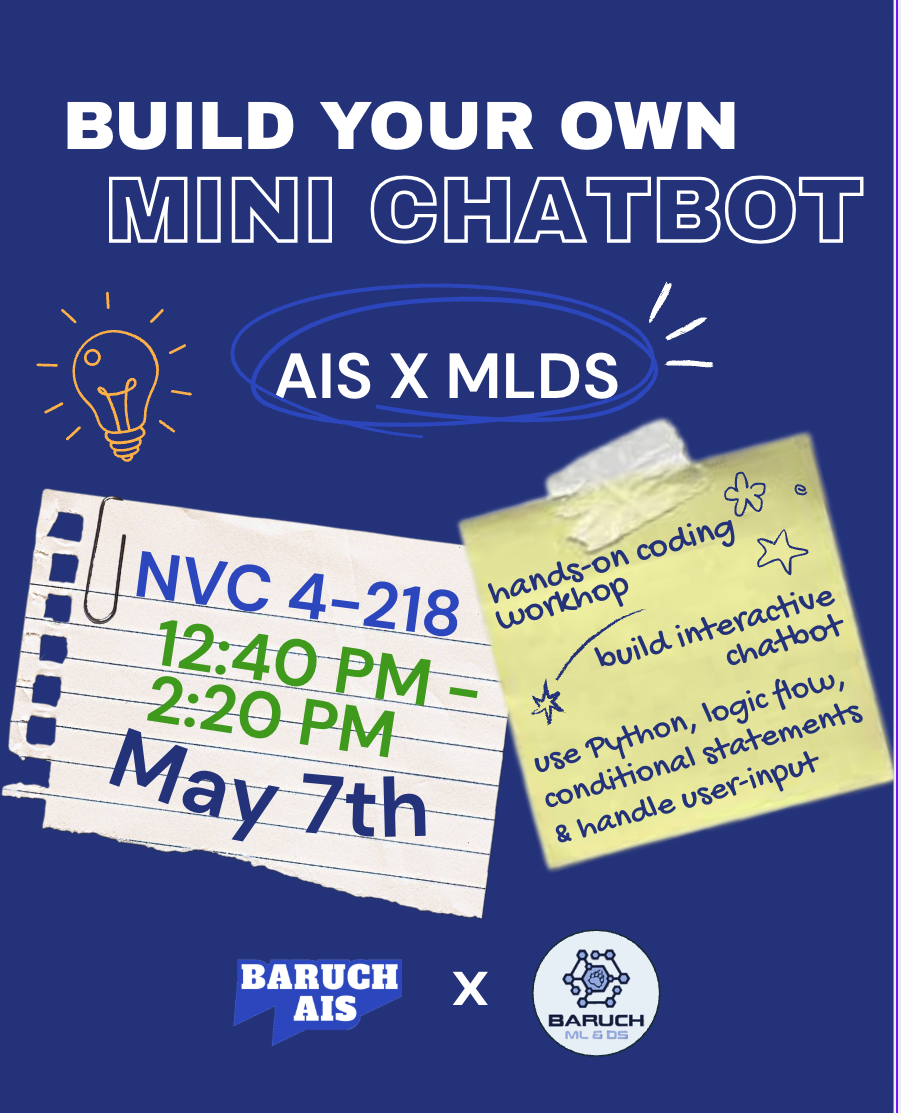

#Building a Chatbot

Overview: This workshops it intended to teach how to simplify complex datasets using PCA. The goal is not math — it is intuition and practical understanding. By the end, you will know how to reduce dimensions and visualize high-dimensional data.”

---
Topics

*   1. Rule-based chatbot (5 mins)
*   2. Words to Vectors (5 mins)
*   3. Retrieval-Based Chatbot (10 mins)
*   4. Build-a-Bot Competition (30 mins)
*   5. From Simple Bots to Real-World Chatbots (5 mins)
*   6. API Chatbots (5 mins)
*   7. Summary (5 mins)

#   1. Rule-based chatbot

A rule-based chatbot follows **if-else rules** to respond.


In [1]:
# Basic chatbot loop
while True:
    user_input = input('You: ')
    if user_input.lower() == 'bye': #single rule for when to break
        print('Bot: Goodbye!')
        break


You: Hi
You: My name is
You: ok
You: Goodbye!
You: bye
Bot: Goodbye!


Now let's teach the bot how to respond to specific inputs by addding some more rule.

In [2]:
while True:
    # Get input from the user and convert it to lowercase
    user_input = input('You: ').lower()

    # Exit condition: stop the loop if user says "bye"
    if user_input == 'bye':
        print('Bot: Goodbye!')
        break

    # Check for keywords in the input
    elif 'hello' in user_input:
        print('Bot: Hi!')

    elif 'how are you' in user_input:
        print('Bot: I\'m doing well!')

    # Default response if no rules match
    else:
        print('Bot: I don\'t understand.')


You: Hi
Bot: I don't understand.
You: hello
Bot: Hi!
You: how are you
Bot: I'm doing well!
You: bye
Bot: Goodbye!


We can add multiple responses to make it feel more natural.

In [ ]:
import random  # used to pick a random response

# Dictionary of possible responses for each keyword
responses = {
    "hello": ["Hi!", "Hello!", "Hey there!"],
    "how are you": ["I'm good!", "Doing great!", "All systems running!"],
    "bye": ["Goodbye!", "See you later!", "Bye!"]
}

while True:
    # Get user input and normalize it to lowercase
    user_input = input("You: ").lower()

    # Exit condition
    if user_input == "bye":
        print("Bot:", random.choice(responses["bye"]))
        break

    matched = False  # keeps track of whether we found a matching rule

    # Loop through each keyword in our response dictionary
    for key in responses:
        if key in user_input:
            # Pick a random response from the list
            print("Bot:", random.choice(responses[key]))
            matched = True
            break  # stop checking once we find a match

    # If no keyword matched, use default response
    if not matched:
        print("Bot: I don't understand.")


While this was fun to play around with if we try unusual inputs like:
- "hey there"
- "what's up?"

You'll notice:
- The bot fails easily
- It only understands exact patterns

This is why we need smarter methods.

#   2. Words to Vectors

### How can we convert text into numbers?

Computers don't understand words — they understand numbers.

We convert sentences into **vectors** (lists of numbers).

Example:

Sentence: "hi there"

Might become:
[1, 0, 1, 0, 0]

Each position represents a word in the vocabulary.

Similar sentences → similar vectors

$\cos(\theta) = \frac{\mathbf{v} \cdot \mathbf{w}}{\|\mathbf{v}\| \|\mathbf{w}\|} \iff \cos(\theta) = \frac{\sum_{i=1}^{n} v_i w_i}{\sqrt{\sum_{i=1}^{n} v_i^2} \; \sqrt{\sum_{i=1}^{n} w_i^2}}$

In [7]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Simple example vectors
A = np.array([[1, 1]])
B = np.array([[1, 0]])

similarity = cosine_similarity(A, B)

print("Cosine similarity between A and B:", similarity[0][0])


Cosine similarity between A and B: 0.7071067811865475


### Measuring Similarity

We compare sentences using **cosine similarity**.

It measures the angle between two vectors:

- 1 → very similar
- 0 → not similar

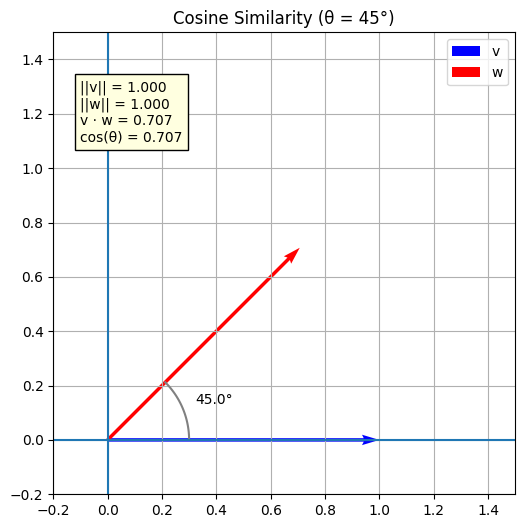

In [5]:
import matplotlib.pyplot as plt

def plot_cosine_similarity(theta_deg):
    # Convert to radians
    theta = np.radians(theta_deg)

    # Define vectors
    v = np.array([1, 0])
    w = np.array([np.cos(theta), np.sin(theta)])

    # Compute cosine similarity
    cos_sim = np.dot(v, w) / (np.linalg.norm(v) * np.linalg.norm(w))

    # Plot
    plt.figure(figsize=(6,6))

    # Plot vectors
    plt.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1, color='blue', label='v')
    plt.quiver(0, 0, w[0], w[1], angles='xy', scale_units='xy', scale=1, color='red', label='w')

    # Angle arc
    arc_theta = np.linspace(0, theta, 100)
    arc_x = 0.3 * np.cos(arc_theta)
    arc_y = 0.3 * np.sin(arc_theta)
    plt.plot(arc_x, arc_y, color='gray')

    # Labels
    plt.text(0.35*np.cos(theta/2), 0.35*np.sin(theta/2), f"{theta_deg:.1f}°")

    # Info box
    info = (
        f"||v|| = {np.linalg.norm(v):.3f}\n"
        f"||w|| = {np.linalg.norm(w):.3f}\n"
        f"v · w = {np.dot(v, w):.3f}\n"
        f"cos(θ) = {cos_sim:.3f}"
    )
    plt.text(-0.1, 1.1, info, bbox=dict(facecolor='lightyellow'))

    # Formatting
    plt.xlim(-0.2, 1.5)
    plt.ylim(-0.2, 1.5)
    plt.axhline(0)
    plt.axvline(0)
    plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.title(f"Cosine Similarity (θ = {theta_deg}°)")
    plt.legend()

    plt.show()

# Example usage
plot_cosine_similarity(45)

θ ≈ 0° → very similar (cos ≈ 1)

θ ≈ 90° → unrelated (cos ≈ 0)

θ ≈ 180° → opposite meaning (cos ≈ -1)


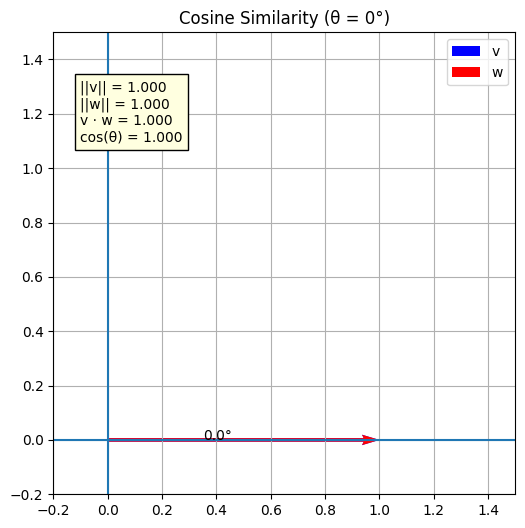

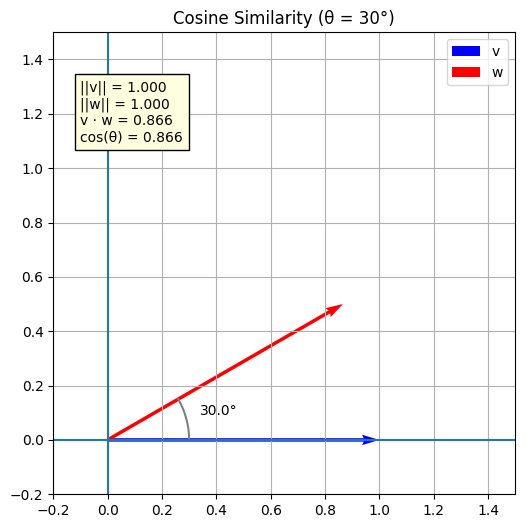

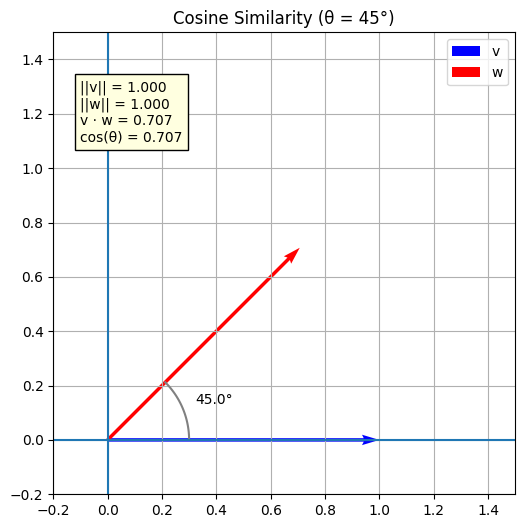

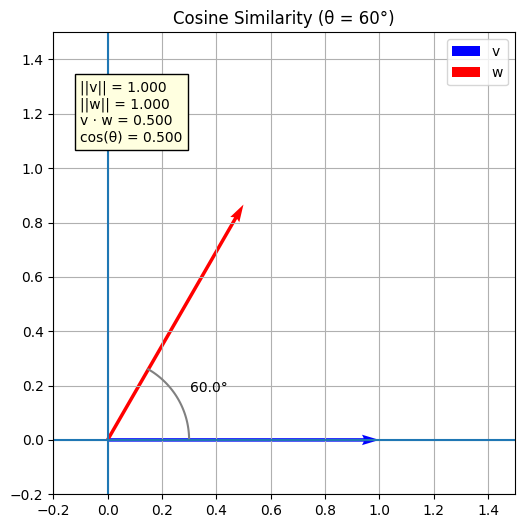

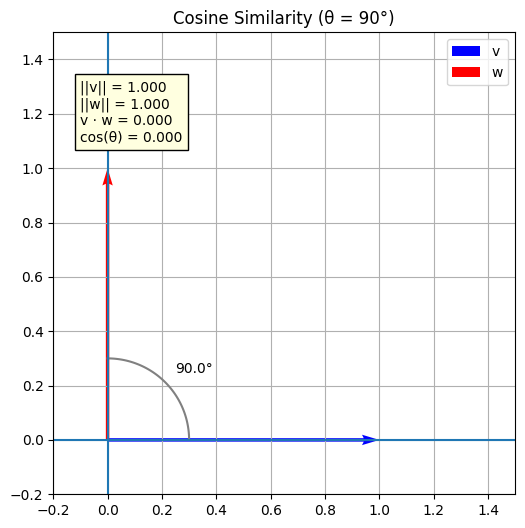

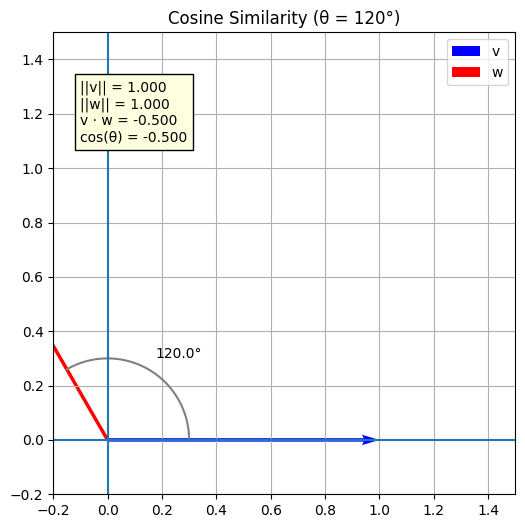

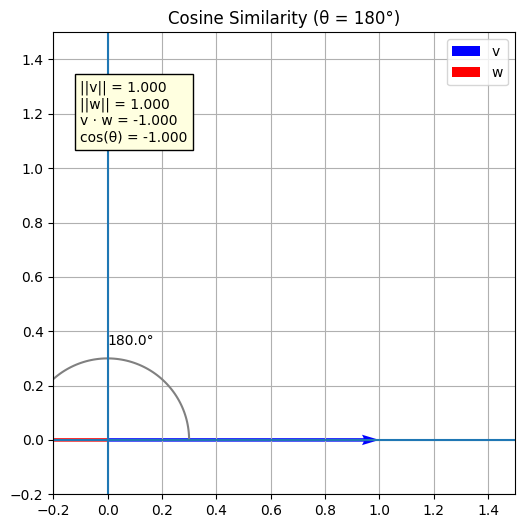

In [6]:
for angle in [0, 30, 45, 60, 90, 120, 180]:
    plot_cosine_similarity(angle)

# 3: Retrieval-Based Chatbot

Instead of rules, we:
1. Store example questions
2. Convert them into numbers
3. Find the closest match

This makes the chatbot more flexible.

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [22]:
# Example dataset: questions and their matching responses
questions = ['hi', 'how are you', 'what is your name']
responses = ['Hello!', 'I\'m good!', 'I\'m a chatbot']

# Convert text into numerical vectors (TF-IDF)
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(questions)

while True:
    user_input = input('You: ')

    # Exit condition
    if user_input.lower() == 'bye':
        print('Bot: Goodbye!')
        break

    # Convert user input into the same vector format
    user_vec = vectorizer.transform([user_input])

    # Compare user input to all known questions
    sims = cosine_similarity(user_vec, X)

    # Find the index of the most similar question
    idx = sims.argmax()

    # If similarity is too low, the bot is unsure
    if sims[0][idx] < 0.2:
        print('Bot: Not sure')
    else:
        # Otherwise, return the best matching response
        print('Bot:', responses[idx])


You: hi
Bot: Hello!
You: bye
Bot: Goodbye!


In [23]:
def add_pair():
    # Ask the user to enter a question and its response
    q = input("Enter a question: ")
    r = input("Enter the bot response: ")

    # Store them in our dataset
    questions.append(q)
    responses.append(r)

    print("✅ Added!")

while True:
    # Ask user what they want to do
    choice = input("\nType 'add' to add data, 'done' to finish: ").lower()

    if choice == "done":
        break
    elif choice == "add":
        add_pair()  # call the function to add a new pair

# Show the final dataset
print("\nFinal dataset:")
for q, r in zip(questions, responses):
    print(f"- {q} -> {r}")


Type 'add' to add data, 'done' to finish: add
Enter a question: Wap
Enter the bot response: bop
✅ Added!

Type 'add' to add data, 'done' to finish: dafq

Type 'add' to add data, 'done' to finish: add
Enter a question: dafq
Enter the bot response: latte
✅ Added!

Type 'add' to add data, 'done' to finish: done

Final dataset:
- hi -> Hello!
- how are you -> I'm good!
- what is your name -> I'm a chatbot
- Wap -> bop
- dafq -> latte


In [24]:
# Create a TF-IDF(Term Frequency-Inverse Document Frequency) vectorizer (turns text into numbers)
vectorizer = TfidfVectorizer()

# Fit the model on our questions and transform them into vectors
X = vectorizer.fit_transform(questions)

# Confirmation message
print("Model updated with class data!")


Model updated with class data!


In [25]:
from sklearn.metrics.pairwise import cosine_similarity

while True:
    # Get user input
    user_input = input("You: ")

    # Exit condition
    if user_input.lower() == "bye":
        print("Bot: Goodbye!")
        break

    # Convert user input into a vector
    user_vec = vectorizer.transform([user_input])

    # Compare input to all stored questions
    similarities = cosine_similarity(user_vec, X)

    # Find the most similar question
    best_match_index = similarities.argmax()

    # Get similarity score (confidence)
    confidence = similarities[0][best_match_index]

    # If similarity is low, the bot is unsure
    if confidence < 0.2:
        print("Bot: I'm not sure I understand")
    else:
        # Otherwise, return the best matching response
        print("Bot:", responses[best_match_index])

You: dafq
Bot: latte
You: wap
Bot: bop
You: done
Bot: I'm not sure I understand 🤔
You: bye
Bot: Goodbye!


# 4: Build-a-Bot Competition

Now YOU help build the chatbot! Split into small groups (2–4 people):

We’re creating 4 different bots!

Each group will build ONE bot:

1. 😂 Funniest Bot  
2. 🎓 Most Useful Bot  
3. 🎨 Most Creative Bot  
4. 🤖 Wildcard Bot (anything goes)

Come up, add questions + responses (5-10), and shape your bot!

In [28]:
# Initialize bots
bots = {
    "funniest": {
        "name": "😂 MemeBot",
        "questions": [],
        "responses": []
    },
    "useful": {
        "name": "🎓 HelperBot",
        "questions": [],
        "responses": []
    },
    "creative": {
        "name": "🎨 ChaosBot",
        "questions": [],
        "responses": []
    },
    "wildcard": {
        "name": "🤖 MysteryBot",
        "questions": [],
        "responses": []
    }
}

def add_to_bot(bot_key):
    bot = bots[bot_key]
    print(f"\nAdding to {bot['name']}")

    q = input("Question: ")
    r = input("Response: ")

    bot["questions"].append(q)
    bot["responses"].append(r)

    print("✅ Added!")

def reset_bot(bot_key):
    bots[bot_key]["questions"].clear()
    bots[bot_key]["responses"].clear()
    print(f"🔄 {bots[bot_key]['name']} has been reset!")

def reset_all():
    for key in bots:
        bots[key]["questions"].clear()
        bots[key]["responses"].clear()
    print("🔄 All bots have been reset!")

while True:
    print("\nChoose an option:")
    print("1. Add to Funniest Bot 😂")
    print("2. Add to Most Useful Bot 🎓")
    print("3. Add to Most Creative Bot 🎨")
    print("4. Add to Wildcard Bot 🤖")
    print("5. Reset ONE bot")
    print("6. Reset ALL bots")
    print("7. Done")

    choice = input("Enter number: ")

    if choice == "7":
        break
    elif choice == "1":
        add_to_bot("funniest")
    elif choice == "2":
        add_to_bot("useful")
    elif choice == "3":
        add_to_bot("creative")
    elif choice == "4":
        add_to_bot("wildcard")

    elif choice == "5":
        print("\nWhich bot do you want to reset?")
        print("1. MemeBot 😂")
        print("2. HelperBot 🎓")
        print("3. ChaosBot 🎨")
        print("4. MysteryBot 🤖")

        r_choice = input("Enter number: ")
        bot_keys = ["funniest", "useful", "creative", "wildcard"]

        if r_choice in ["1","2","3","4"]:
            reset_bot(bot_keys[int(r_choice)-1])
        else:
            print("Invalid choice")

    elif choice == "6":
        confirm = input("Are you sure? (yes/no): ")
        if confirm.lower() == "yes":
            reset_all()

    else:
        print("Invalid choice")

print("\n✅ Setup complete!")


Choose an option:
1. Add to Funniest Bot 😂
2. Add to Most Useful Bot 🎓
3. Add to Most Creative Bot 🎨
4. Add to Wildcard Bot 🤖
5. Reset ONE bot
6. Reset ALL bots
7. Done
Enter number: 5

Which bot do you want to reset?
1. MemeBot 😂
2. HelperBot 🎓
3. ChaosBot 🎨
4. MysteryBot 🤖
Enter number: 1
🔄 😂 MemeBot has been reset!

Choose an option:
1. Add to Funniest Bot 😂
2. Add to Most Useful Bot 🎓
3. Add to Most Creative Bot 🎨
4. Add to Wildcard Bot 🤖
5. Reset ONE bot
6. Reset ALL bots
7. Done
Enter number: 7

✅ Setup complete!


In [27]:
vectorizers = {}
X_data = {}

for key in bots:
    if len(bots[key]["questions"]) > 0:
        vectorizer = TfidfVectorizer()
        X = vectorizer.fit_transform(bots[key]["questions"])

        vectorizers[key] = vectorizer
        X_data[key] = X

print("✅ All bots trained!")

✅ All bots trained!


In [ ]:
while True:
    print("\nWhich bot do you want to talk to?")
    print("1. 😂 MemeBot")
    print("2. 🎓 HelperBot")
    print("3. 🎨 ChaosBot")
    print("4. 🤖 MysteryBot")
    print("5. Exit")

    choice = input("Enter number: ")

    if choice == "5":
        break

    bot_keys = ["funniest", "useful", "creative", "wildcard"]

    if choice in ["1","2","3","4"]:
        key = bot_keys[int(choice)-1]

        if key not in vectorizers:
            print("⚠️ This bot has no data yet!")
            continue

        user_input = input("You: ")

        user_vec = vectorizers[key].transform([user_input])
        similarities = cosine_similarity(user_vec, X_data[key])
        idx = similarities.argmax()

        print("Bot:", bots[key]["responses"][idx])
    else:
        print("Invalid choice")

### 🏆 Voting Time!

Vote for:

- 😂 Funniest Bot  
- 🎓 Most Useful Bot  
- 🎨 Most Creative Bot  

Which one did you like best?

# 5. From Simple Bots to Real-World Chatbots

You've built a chatbot but how does this connect to real AI systems?

###  Your Chatbot vs Modern AI

| **Your Chatbot (Retrieval-Based)**                                                                                           | **Modern AI (Generative Models)**                                                                                                      |
| ---------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------------------------- |
| **TF-IDF vectors** (Term Frequency-Inverse Document Frequency) <br>→ Turns text into numbers by counting important words (gives less weight to common words like “the”) | **Embeddings**  <br>→ Dense numeric representations where similar meanings are close together (captures context, not just word counts) |
| **Cosine similarity**  <br>→ Measures how similar two pieces of text are by comparing angles between vectors                 | **Deep learning**  <br>→ Neural networks that learn patterns in language from huge amounts of data                                     |
| **Picks best answer**  <br>→ Chooses the closest matching response from a predefined list                                    | **Generates new text**  <br>→ Creates original responses word-by-word based on learned patterns                                        |
| **Small dataset**  <br>→ Works with a limited set of example sentences                                                       | **Trained on massive data**  <br>→ Learned from billions of words across books, websites, etc.                                         |

What would make this chatbot feel more human or useful?

- Memory 🧩
- Better understanding 🧠
- Personality 🎭
- Learning over time 📈
- Context awareness 🔗

### Everything suggested, memory, understanding, and personality is exactly what modern AI systems are built to do.

# 6. API Chatbots

Instead of writing all the logic ourselves, we send a message to an AI model, and it responds.

In [ ]:
from openai import OpenAI

client = OpenAI()

while True:
    user_input = input("You: ")

    if user_input.lower() == "bye":
        print("Bot: Goodbye!")
        break

    response = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role": "user", "content": user_input}
        ]
    )

    print("Bot:", response.choices[0].message.content)

⚠️ This requires an API key.

In real applications:
- You sign up for an API
- Get a key
- Use it in your code

(We won’t run this live unless a key is set up.)

# 7. Summary

What You Learned

- How chatbots work at a basic level  
- How to turn text into numbers  
- How similarity powers responses  
- How real AI systems are built  

You went from rules → real AI systems in one session.